# Load the neomod model into a 4D array

In [16]:
import re
import pandas as pd
from urllib.request import urlopen
from io import StringIO
import numpy as np

url = "https://www2.boulder.swri.edu/~davidn/NEOMOD_Simulator/input_neomod3.dat"


text = urlopen(url).read().decode("utf-8", errors="ignore")
lines = text.splitlines()

# to find the header row
header_idx = next(
    i for i, ln in enumerate(lines)
    if re.match(r"^\s*iH\s+ia\s+ie\s+ii\s+binned\s+mod\.\s+nu6\b", ln)
)

# merging binned and mod. into one, otherwise it becomes weird :\
raw_tokens = re.split(r"\s+", lines[header_idx].strip())
names = []
i = 0
while i < len(raw_tokens):
    if raw_tokens[i] == "binned" and i + 1 < len(raw_tokens) and raw_tokens[i+1].startswith("mod."):
        names.append("binned mod.")
        i += 2
    else:
        names.append(raw_tokens[i])
        i += 1

#skips blank or dashed lines
data_lines = []
for ln in lines[header_idx + 1:]:
    s = ln.strip()
    if not s or set(s) <= set("- "):    # separators/blank
        continue
    if re.match(r"^\d", s):             
        data_lines.append(s)


df = pd.read_csv(StringIO("\n".join(data_lines)), sep=r"\s+", header=None, names=names)


df.head()

,iH,ia,ie,ii,binned mod.,nu6,3:1,5:2,7:3,8:3,9:4,11:5,2:1,inner,Hun,Pho,JFC
0,1,4,1,1,1.454600e-08,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,4,1,2,2.115800e-08,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1,4,1,3,1.917400e-08,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1,4,1,4,3.305900e-09,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1,4,1,10,1.983600e-08,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [17]:
#to calc center of bins
n_H, H_min, H_max = 52, 15.0, 28.0
n_a, a_min, a_max = 42, 0.0, 4.2
n_e, e_min, e_max = 25, 0.0, 1.0
n_i, i_min, i_max = 22, 0.0, 88.0

da = (a_max - a_min)/(n_a) #bin width
de = (e_max - e_min)/(n_e)
di = (i_max - i_min)/(n_i)
dH = (H_max - H_min)/n_H

#bin center coords
a_center = a_min + (np.arange(n_a) + 0.5) * da
e_center = e_min + (np.arange(n_e) + 0.5) * de
i_center = i_min + (np.arange(n_i) + 0.5) * di
H_center = H_min + (np.arange(n_H) + 0.5) * dH

array4D = np.zeros((n_H, n_a, n_e, n_i))

idx = df[['iH', 'ia', 'ie', 'ii']].astype(int).values - 1  # 0-based indices
vals = df['binned mod.'].astype(float).values
array4D[idx[:,0], idx[:,1], idx[:,2], idx[:,3]] = vals

df["a_AU"] = a_min + (df["ia"] - 0.5) * da 
df["e"] = e_min + (df["ie"] - 0.5) * de

In [18]:
array4D.sum()

np.float64(11432917.944222083)

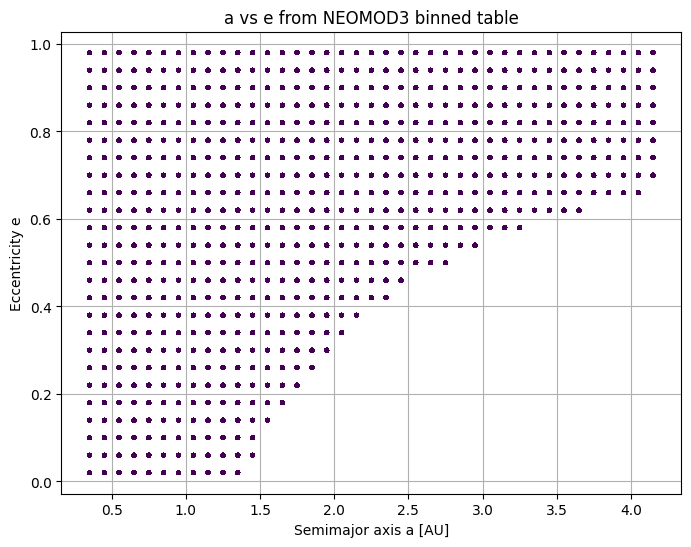

In [19]:
import matplotlib.pyplot as plt



#plotting (scatter)
plt.figure(figsize=(8,6))
plt.scatter(df["a_AU"], df["e"], s=5, alpha=0.7, c=df["binned mod."])

plt.xlabel("Semimajor axis a [AU]")
plt.ylabel("Eccentricity e")
plt.title("a vs e from NEOMOD3 binned table")
plt.grid(True)
plt.show()

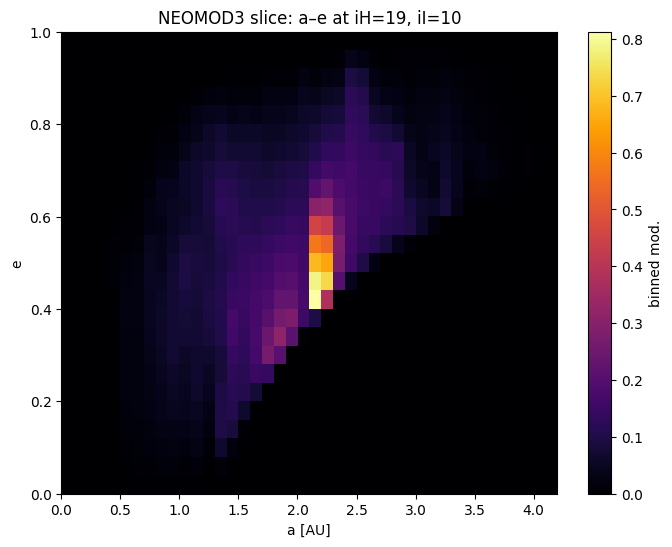

In [112]:
#example slice with fixed iH = 10, ii=5
# make a movie going through different h and i
h_fix = 18
i_fix = 9
slice2D = array4D[h_fix, : , : ,i_fix] #from n_a to n_e 


#plotting (scatter)
plt.figure(figsize=(8,6))
plt.imshow(slice2D.T, origin = "lower", extent = [a_min, a_max, e_min, e_max], aspect = "auto", cmap = "inferno")

plt.colorbar(label="binned mod.")
plt.xlabel("a [AU]")
plt.ylabel("e")
plt.title(f"NEOMOD3 slice: a–e at iH={h_fix+1}, iI={i_fix+1}")
plt.show()

In [21]:
# the file is in https://www2.boulder.swri.edu/~davidn/NEOMOD_Simulator/

# plot a few 2d slices through the 4d distribution

ae_slice = n[1, :, :, 1]

NameError: name 'n' is not defined

# Sampling in (d, d-dot) space

In [24]:
ra, dec = 10, 20           # degrees
dra, ddec = 0.12, 0.22     # degrees/day

# things that we don't know
d, ddot = None, None       # AU, km/s

In [ ]:
import numpy as np

doptions    = np.arange(0, 100, 0.1)
ddotoptions = np.arange(0, 100, 0.1)

In [ ]:
# a, e, i, argPeri, node, M = ?

for d in doptions:
    for ddot in ddotoptions:
        # transform (ra, dec, dra, ddec, d, ddot) --> (a, e, i, argPeri, node, M)
        ...
        #     1. transform (ra, dec, dra, ddec, d, ddot) ---> (x, y, z, vx, vy, vz)
        #        Note: (xyz, vxyz) are in heliocentric coordinates

        #     2. transform (x, y, z, vx, vy, vz) --> (a, e, i, argPeri, node, M)
        
        # then, look up the value in the NEOMOD 4D array for the (a, e, i) that we obtain
        ...

In [25]:
import numpy as np
import astropy.units as u
from astropy.time import Time


ra_deg   = 10.0          
dec_deg  = 20.0          
dra_deg_per_day  = 0.12  
ddec_deg_per_day = 0.22  
d_au     = 1.5           # guessing a random value?
ddot_kms = 10.0          #
obstime  = Time("2025-09-16T00:00:00")

# if the RA rate is d alpha/dt and not u alpha.cos delta then this should be set to True to multiply by cos delta
ra_rate_is_plain_dalpha = False


In [87]:
from numpy import sin, cos

def sky_basis(ra_rad, dec_rad):
    
    l_hat = np.array([cos(dec_rad)*cos(ra_rad), # vector that points to object's pos on sky
                      cos(dec_rad)*sin(ra_rad),
                      sin(dec_rad)])
    e_ra  = np.array([-sin(ra_rad),  cos(ra_rad), 0.0]) # vector towards increasing RA - points east, 90 deg to l_hat
    e_dec = np.array([-sin(dec_rad)*cos(ra_rad), # vector towards increasing dec - points north
                      -sin(dec_rad)*sin(ra_rad),
                       cos(dec_rad)])
    return l_hat, e_ra, e_dec


In [88]:
AU_km = 149_597_870.7

def observables_to_geocentric_state(ra_deg, dec_deg, dra_deg_per_day, ddec_deg_per_day,
                                    d_au, ddot_kms, ra_rate_is_plain_dalpha=False):
    # converting from degrees to radians
    ra  = np.deg2rad(ra_deg) 
    dec = np.deg2rad(dec_deg)
    l_hat, e_ra, e_dec = sky_basis(ra, dec)

    # angular rate conversion from deg/day to rad/s
    dra  = np.deg2rad(dra_deg_per_day)  / 86400.0
    ddec = np.deg2rad(ddec_deg_per_day) / 86400.0

    # if the RA rate is plain d alpha/dt, convert to u alpha⋅cos delta sky-plane rate
    if ra_rate_is_plain_dalpha:
        dra *= np.cos(dec)

    d_km = d_au * AU_km

    # multiplying l_hat by the rand dist. value gives actual geocentric pos vector of obj
    r_geo = d_km * l_hat 

    # speed
    v_rad = ddot_kms * l_hat
    v_tan = d_km * (dra * e_ra + ddec * e_dec)
    v_geo = v_rad + v_tan

    return r_geo, v_geo

# run to check
r_geo, v_geo = observables_to_geocentric_state(
    ra_deg, dec_deg, dra_deg_per_day, ddec_deg_per_day,
    d_au, ddot_kms, ra_rate_is_plain_dalpha
)
print("geocentric position km:", r_geo)
print("geocentric velocity km/s:", v_geo)


geocentric position km: [2.07660524e+08 3.66161533e+07 7.67482278e+07]
geocentric velocity km/s: [ 4.95063099  6.39637544 12.79126305]


In [89]:
from astropy.coordinates import EarthLocation, get_body_barycentric_posvel, solar_system_ephemeris 
from astropy.time import Time


# Rubin Observatory Chile MPC code X05
rubin_location = EarthLocation.from_geodetic( 
    lon=-70.7366*u.deg,   # longitude (west is negative)
    lat=-30.2407*u.deg,   # latitude
    height=2647*u.m       # elevation
)
rubin_location


<EarthLocation (1820172.05480914, -5208258.58244767, -3194786.63402748) m>

In [90]:

obstime = Time("2025-09-16T00:00:00") 

# earth's barycentric vector rel to sun
with solar_system_ephemeris.set('de432s'): 
    rE_bary, vE_bary = get_body_barycentric_posvel('earth', obstime)

# convert to km and km/s arrays
rE = np.array([rE_bary.x.to(u.km).value, 
               rE_bary.y.to(u.km).value,
               rE_bary.z.to(u.km).value])
vE = np.array([vE_bary.x.to(u.km/u.s).value,
               vE_bary.y.to(u.km/u.s).value,
               vE_bary.z.to(u.km/u.s).value])

print("earth heliocentric position km:", rE) 
print("earth heliocentric velocity km/s:", vE) 


earth heliocentric position km: [ 1.48729971e+08 -1.74898306e+07 -7.55902288e+06]
earth heliocentric velocity km/s: [ 3.15172845 27.02778897 11.71628245]


In [91]:
# converting rubins loc to GCRS
obs_geo = rubin_location.get_gcrs(obstime)

r_obs = np.array([obs_geo.cartesian.x.to(u.km).value,
                  obs_geo.cartesian.y.to(u.km).value,
                  obs_geo.cartesian.z.to(u.km).value])

print("observer offset wrt earth center in km:", r_obs)


observer offset wrt earth center in km: [ 1338.94924559 -5350.33318771 -3197.93606972]


In [92]:
def geo_to_topo(r_geo_km, v_geo_kms, obstime):
    
    # convert r_geo, v_geo for obj to heliocentric r_topo, v_topo for an observer at rubin
    obstime = Time(obstime)

    # earth's barycentric (heliocentric) state
    with solar_system_ephemeris.set('de432s'):
        rE_bary, vE_bary = get_body_barycentric_posvel('earth', obstime)

    rE = np.array([rE_bary.x.to(u.km).value,
                   rE_bary.y.to(u.km).value,
                   rE_bary.z.to(u.km).value])
    vE = np.array([vE_bary.x.to(u.km/u.s).value,
                   vE_bary.y.to(u.km/u.s).value,
                   vE_bary.z.to(u.km/u.s).value])

    # observer's offset from center of earth
    obs_geo = rubin_location.get_gcrs(obstime)
    r_obs = np.array([obs_geo.cartesian.x.to(u.km).value,
                      obs_geo.cartesian.y.to(u.km).value,
                      obs_geo.cartesian.z.to(u.km).value])

    # adding the offsets
    r_topo = rE + r_obs + r_geo_km
    v_topo = vE + v_geo_kms

    return r_topo, v_topo


In [97]:
# random test numbers
r_geo_rand = np.array([1e6, 2e6, 3e6])       # km
v_geo_rand = np.array([1.0, -2.0, 0.5])      # km/s

#r_helio, v_helio = geo_to_topo(r_geo_rand, v_geo_rand, obstime)
r_helio, v_helio = geo_to_topo(r_geo, v_geo, obstime)
print("Heliocentric position [km]:", r_helio)
print("Heliocentric velocity [km/s]:", v_helio)



Heliocentric position [km]: [3.56391834e+08 1.91209724e+07 6.91860069e+07]
Heliocentric velocity [km/s]: [ 8.10235943 33.42416442 24.5075455 ]


In [98]:
mu_sun = 1.32712440018e11  # [km^3/s^2] gm of the sun

r_vec = np.array(r_helio, dtype=float)
v_vec = np.array(v_helio, dtype=float)

print("r in km:", r_vec)
print("v in km/s:", v_vec)


r in km: [3.56391834e+08 1.91209724e+07 6.91860069e+07]
v in km/s: [ 8.10235943 33.42416442 24.5075455 ]


In [99]:
def safe_arccos(x):
    
    return np.arccos(np.clip(x, -1.0, 1.0))

r = np.array(r_vec, dtype=float)
v = np.array(v_vec, dtype=float)
R = np.linalg.norm(r)
V = np.linalg.norm(v)

print("R = |r| km:", R)
print("V = |v| km/s:", V)


R = |r| km: 363548421.58356273
V = |v| km/s: 42.230827386611566


In [100]:
import adam_core.coordinates

In [103]:
import pyarrow as pa
import numpy as np
from adam_core.time import Timestamp
from adam_core.coordinates import CartesianCoordinates, Origin
from adam_core.constants import KM_P_AU, S_P_DAY
from astropy.time import Time
from adam_core.orbits import Orbits


#r_helio = np.array([ 1.49731310e+08, -1.54951809e+07, -4.56222082e+06 ])  # km
#v_helio = np.array([ 4.15172845, 25.02778897, 12.21628245 ])              # km/s
r_helio = np.array([3.56391834e+08, 1.91209724e+07, 6.91860069e+07])
v_helio = np.array([ 8.10235943, 33.42416442, 24.5075455 ]) 


obstime = Time(["2025-09-16T00:00:00"], scale="tdb")  # Note converted this to a list    

if r_helio.ndim == 1:
    r_helio = r_helio[np.newaxis, :]
    v_helio = v_helio[np.newaxis, :]


cartesian_coordinates = CartesianCoordinates.from_kwargs(
    x=r_helio[:, 0] / KM_P_AU,
    y=r_helio[:, 1] / KM_P_AU,
    z=r_helio[:, 2] / KM_P_AU,
    vx=v_helio[:, 0] / KM_P_AU * S_P_DAY,
    vy=v_helio[:, 1] / KM_P_AU * S_P_DAY,
    vz=v_helio[:, 2] / KM_P_AU * S_P_DAY,
    time=Timestamp.from_astropy(obstime),
    origin=Origin.from_kwargs(code=pa.repeat("SUN", len(r_helio))),
    frame="equatorial" # ecliptic is the other choice
)

keplerian_coordinates = cartesian_coordinates.to_keplerian()
keplerian_coordinates_df = keplerian_coordinates.to_dataframe()
#print(keplerian_coordinates.to_dataframe())
keplerian_coordinates_df

# Might be useful to store them into an orbits object:
orbits = Orbits.from_kwargs(
    orbit_id=[f"orbit_{i:08d}" for i in range(len(cartesian_coordinates))],
    coordinates=cartesian_coordinates,
)
# The Orbits class expects cartesian coordinates but its trivial to convert
print(orbits.coordinates.to_keplerian().to_dataframe())
print(orbits.coordinates.to_cometary().to_dataframe())








          a        e          i        raan         ap          M  time.days  \
0 -0.842198  3.66962  35.476751  347.287665  353.93717  53.615783      60934   

   time.nanos                                  covariance.values origin.code  
0           0  [nan, nan, nan, nan, nan, nan, nan, nan, nan, ...         SUN  
         q        e          i        raan         ap          tp  time.days  \
0  2.24835  3.66962  35.476751  347.287665  353.93717  60891.9554      60934   

   time.nanos                                  covariance.values origin.code  
0           0  [nan, nan, nan, nan, nan, nan, nan, nan, nan, ...         SUN  


In [104]:
keplerian_coordinates_df

,a,e,i,raan,ap,M,time.days,time.nanos,covariance.values,origin.code
0,-0.842198,3.66962,35.476751,347.287665,353.93717,53.615783,60934,0,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...",SUN


In [105]:
from adam_core.utils import get_perturber_state
from adam_core.coordinates.origin import OriginCodes

times = Timestamp.from_mjd(np.arange(59000, 59100, 1))

perturber_state = get_perturber_state(OriginCodes.EARTH, times)

In [106]:
perturber_state

CartesianCoordinates(size=100)

In [107]:
from scipy.interpolate import RegularGridInterpolator

# so that log(0) doesn't happen
_eps = 1e-300
log_grid = np.log(array4D + _eps)

interp4D = RegularGridInterpolator(
    (H_center, a_center, e_center, i_center),
    log_grid,
    bounds_error=False,          
    fill_value=-np.inf           
)


In [108]:
def neomod3_slice_ae(H0, i0, a_grid, e_grid): #fixes H, i, and creates a mesh of a, e
    
    pts = np.column_stack([np.full(a_grid.size, H0),
                           a_grid.ravel(),
                           e_grid.ravel(),
                           np.full(a_grid.size, i0)])
    log_w = interp4D(pts)             
    w = np.exp(log_w).reshape(a_grid.shape)
    return w


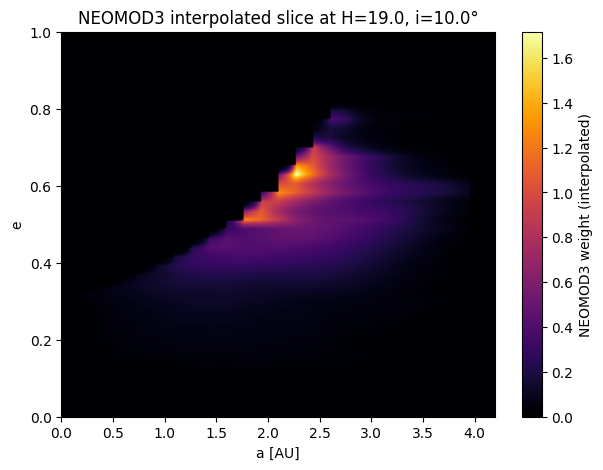

In [109]:
import matplotlib.pyplot as plt

# fixed vals
H0 = 19.0         # abs magnitude
i0 = 10.0         # deg


Na, Ne = 200, 200
a_grid = np.linspace(a_min, a_max, Na)
e_grid = np.linspace(e_min, e_max, Ne)
A, E = np.meshgrid(a_grid, e_grid, indexing="xy")

W = neomod3_slice_ae(H0, i0, A, E)    

plt.figure(figsize=(7,5))
im = plt.imshow(
    W.T, origin="lower",
    extent=[a_min, a_max, e_min, e_max],
    aspect="auto", cmap="inferno"
)
plt.colorbar(im, label="NEOMOD3 weight (interpolated)")
plt.xlabel("a [AU]")
plt.ylabel("e")
plt.title(f"NEOMOD3 interpolated slice at H={H0}, i={i0}°")
plt.show()


In [111]:
def neomod3_at_orbit(a_val, e_val, H0, i0):
    log_w = interp4D([[H0, a_val, e_val, i0]])[0]
    return float(np.exp(log_w))


#a_val, e_val = 0.915, 0.109 # from the adam_core result table
a_val, e_val = -0.84, 3.66 
score = neomod3_at_orbit(a_val, e_val, H0=19.0, i0=25.9)
print("interpolated NEOMOD3 weight:", score)


interpolated NEOMOD3 weight: 0.0


In [114]:
%pip install adam_core

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
